# NPL 예측 ML 모델링 v3 — NPL 변화량(diff) 예측

## 핵심 아이디어

v1/v2는 NPL 절대값을 예측 → 하락 추세를 학습해서 반등 구간을 못 잡음  
v3는 **NPL 변화량(+/-)을 예측** → 추세 전환 포착이 더 쉬움

예측 흐름:
```
현재 분기 거시지표 + 현재 NPL
    -> 모델이 '다음 분기 NPL 변화량' 예측
    -> 최종 NPL = 현재 NPL + 예측 변화량
```

Train: 2011Q4 ~ 2022Q4 / Test: 2023Q1 ~ 2025Q3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model  import LinearRegression, Ridge, Lasso
from sklearn.ensemble      import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import mean_squared_error, mean_absolute_error, r2_score
from xgboost               import XGBRegressor
from lightgbm              import LGBMRegressor

plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('준비 완료')

준비 완료


In [2]:
# -------------------------------------------------------
# 1. 데이터 로드 및 피처 엔지니어링
# -------------------------------------------------------
df = pd.read_csv('../data/processed/dataset.csv')

macro_cols = ['base_rate', 'deposit_rate', 'loan_rate',
              'unemployment_rate', 'household_loan_balance']

# 거시지표 lag1, diff1
for col in macro_cols:
    df[col + '_lag1']  = df[col].shift(1)
    df[col + '_diff1'] = df[col].diff(1)

# 이전 분기 NPL (자기회귀 신호)
df['NPL_lag1'] = df['NPL비율'].shift(1)

# NPL 변화량 피처들 (현재 분기 NPL 방향성)
df['NPL_diff1']  = df['NPL비율'].diff(1)          # 1분기 전 대비 변화
df['NPL_diff2']  = df['NPL비율'].diff(2)          # 2분기 전 대비 변화 (추세 강도)

# [핵심 변경] 예측 타겟: NPL 절대값이 아닌 '다음 분기 변화량'
# target = NPL(t+1) - NPL(t)
df['target_diff'] = df['NPL비율'].shift(-1) - df['NPL비율']

# 현재 NPL (예측 후 최종 NPL 복원에 사용)
df['current_npl'] = df['NPL비율']

df_model = df.dropna().reset_index(drop=True)

print('모델링 데이터 크기:', df_model.shape)
print('기간:', df_model['quarter'].iloc[0], '~', df_model['quarter'].iloc[-1])
print()
print('타겟 변수(변화량) 기술통계:')
print(df_model['target_diff'].describe().round(4))

모델링 데이터 크기: (54, 25)
기간: 2012Q2 ~ 2025Q3

타겟 변수(변화량) 기술통계:
count    54.0000
mean     -0.0170
std       0.1007
min      -0.2900
25%      -0.0700
50%      -0.0100
75%       0.0175
max       0.3900
Name: target_diff, dtype: float64


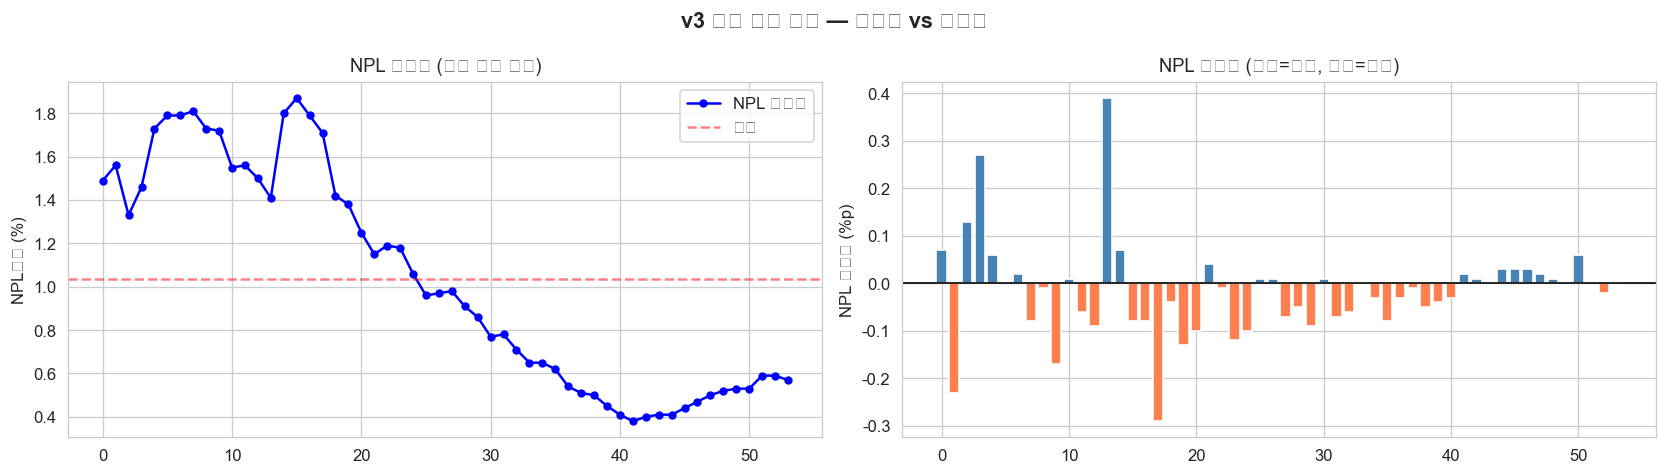

In [3]:
# -------------------------------------------------------
# 2. 변화량 타겟 시각화 — 예측 난이도 확인
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# NPL 절대값 vs 변화량 비교
ax = axes[0]
ax.plot(df_model['NPL비율'].values, 'bo-', linewidth=1.5, markersize=4, label='NPL 절대값')
ax.set_title('NPL 절대값 (추세 전환 있음)', fontsize=11)
ax.set_ylabel('NPL비율 (%)')
ax.axhline(df_model['NPL비율'].mean(), color='red', linestyle='--', alpha=0.5, label='평균')
ax.legend()

ax = axes[1]
colors_bar = ['coral' if v < 0 else 'steelblue' for v in df_model['target_diff']]
ax.bar(range(len(df_model)), df_model['target_diff'], color=colors_bar)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('NPL 변화량 (파랑=상승, 빨강=하락)', fontsize=11)
ax.set_ylabel('NPL 변화량 (%p)')

fig.suptitle('v3 타겟 변수 비교 — 절대값 vs 변화량', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/fig_v3_target.png', bbox_inches='tight')
plt.show()

In [4]:
# -------------------------------------------------------
# 3. Train / Test 분할
# -------------------------------------------------------
feature_cols = (
    macro_cols
    + [c + '_lag1'  for c in macro_cols]
    + [c + '_diff1' for c in macro_cols]
    + ['NPL_lag1', 'NPL_diff1', 'NPL_diff2']  # NPL 자기회귀 + 추세 피처
)

train_mask = df_model['quarter'] <= '2022Q4'
test_mask  = df_model['quarter'] >= '2023Q1'

X_train       = df_model.loc[train_mask, feature_cols]
y_train       = df_model.loc[train_mask, 'target_diff']   # 변화량 예측
npl_train     = df_model.loc[train_mask, 'current_npl'].values  # 복원용

X_test        = df_model.loc[test_mask, feature_cols]
y_test_diff   = df_model.loc[test_mask, 'target_diff']    # 실제 변화량
npl_test      = df_model.loc[test_mask, 'current_npl'].values   # 복원용
test_quarters = df_model.loc[test_mask, 'quarter'].tolist()

# 최종 비교용: 실제 다음 분기 NPL (복원값)
y_test_npl = npl_test + y_test_diff.values

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {len(X_train)}개, Test: {len(X_test)}개, 피처: {len(feature_cols)}개')
print('\n테스트 기간 실제 NPL 변화량:')
for q, diff in zip(test_quarters, y_test_diff):
    arrow = '+' if diff >= 0 else ''
    print(f'  {q}: {arrow}{diff:.3f}%p')

Train: 43개, Test: 11개, 피처: 18개

테스트 기간 실제 NPL 변화량:
  2023Q1: +0.000%p
  2023Q2: +0.030%p
  2023Q3: +0.030%p
  2023Q4: +0.030%p
  2024Q1: +0.020%p
  2024Q2: +0.010%p
  2024Q3: +0.000%p
  2024Q4: +0.060%p
  2025Q1: +0.000%p
  2025Q2: -0.020%p
  2025Q3: +0.000%p


In [5]:
# -------------------------------------------------------
# 4. 모델 학습 (기본 파라미터)
# -------------------------------------------------------
models = {
    'Linear Regression': (LinearRegression(),                       True),
    'Ridge':             (Ridge(alpha=1.0),                         True),
    'Lasso':             (Lasso(alpha=0.001),                       True),
    'Random Forest':     (RandomForestRegressor(
                              n_estimators=200, max_depth=4,
                              random_state=42),                     False),
    'XGBoost':           (XGBRegressor(
                              n_estimators=200, max_depth=3,
                              learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42, verbosity=0),        False),
    'LightGBM':          (LGBMRegressor(
                              n_estimators=200, max_depth=3,
                              learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42, verbose=-1),         False),
}

results       = []
pred_npl_dict = {}   # 최종 NPL 예측값 저장

for name, (model, use_scale) in models.items():
    Xtr = X_train_scaled if use_scale else X_train.values
    Xte = X_test_scaled  if use_scale else X_test.values

    # 변화량 학습
    model.fit(Xtr, y_train)

    # 변화량 예측 -> 최종 NPL 복원
    pred_diff_train = model.predict(Xtr)
    pred_diff_test  = model.predict(Xte)
    pred_npl_test   = npl_test + pred_diff_test   # 현재 NPL + 예측 변화량
    pred_npl_dict[name] = pred_npl_test

    # 평가: 복원된 NPL vs 실제 NPL 기준으로 계산
    rmse_train = np.sqrt(mean_squared_error(npl_train + model.predict(Xtr), npl_train + pred_diff_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test_npl, pred_npl_test))
    mae_test   = mean_absolute_error(y_test_npl, pred_npl_test)
    r2_test    = r2_score(y_test_npl, pred_npl_test)
    mape_test  = np.mean(np.abs((y_test_npl - pred_npl_test) / y_test_npl)) * 100

    results.append({
        '모델':         name,
        'RMSE(Test)':  round(rmse_test,  4),
        'MAE(Test)':   round(mae_test,   4),
        'R2(Test)':    round(r2_test,    4),
        'MAPE(Test)':  round(mape_test,  2),
    })

result_df = pd.DataFrame(results).sort_values('RMSE(Test)')
print('=== v3 모델 성능 (NPL 변화량 예측 후 복원) ===')
print(result_df.to_string(index=False))

=== v3 모델 성능 (NPL 변화량 예측 후 복원) ===
               모델  RMSE(Test)  MAE(Test)  R2(Test)  MAPE(Test)
         LightGBM      0.0171     0.0123    0.9112        2.37
    Random Forest      0.0344     0.0283    0.6422        5.61
          XGBoost      0.0646     0.0493   -0.2625        9.97
            Ridge      0.2338     0.2288  -15.5181       44.37
            Lasso      0.4232     0.4189  -53.1185       81.15
Linear Regression      0.5961     0.5903 -106.3876      114.46


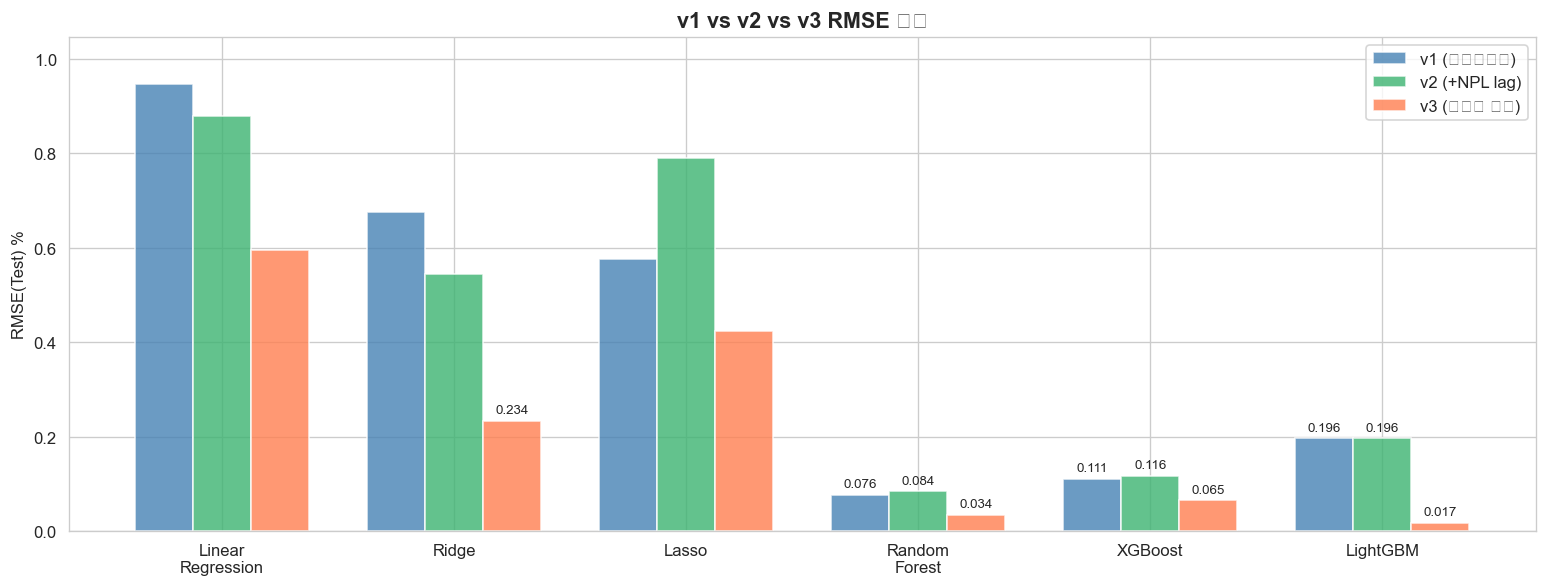

In [6]:
# -------------------------------------------------------
# 5. 버전별 성능 비교 (v1 / v2 / v3)
# -------------------------------------------------------
compare_data = {
    '모델': ['Linear\nRegression', 'Ridge', 'Lasso',
            'Random\nForest', 'XGBoost', 'LightGBM'],
    'v1':  [0.9466, 0.6758, 0.5752, 0.0761, 0.1106, 0.1959],
    'v2':  [0.8788, 0.5437, 0.7894, 0.0839, 0.1162, 0.1963],
    'v3':  [result_df.set_index('모델').loc[m, 'RMSE(Test)']
            for m in ['Linear Regression', 'Ridge', 'Lasso',
                      'Random Forest', 'XGBoost', 'LightGBM']],
}
compare_df = pd.DataFrame(compare_data)

x     = np.arange(len(compare_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width, compare_df['v1'], width, label='v1 (거시지표만)',          color='steelblue', alpha=0.8)
b2 = ax.bar(x,         compare_df['v2'], width, label='v2 (+NPL lag)',             color='mediumseagreen', alpha=0.8)
b3 = ax.bar(x + width, compare_df['v3'], width, label='v3 (변화량 예측)',         color='coral', alpha=0.8)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h < 0.3:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(compare_df['모델'])
ax.set_ylabel('RMSE(Test) %')
ax.set_title('v1 vs v2 vs v3 RMSE 비교', fontsize=13, fontweight='bold')
ax.set_ylim(0, min(1.2, compare_df[['v1','v2','v3']].max().max() + 0.1))
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_v3_comparison.png', bbox_inches='tight')
plt.show()

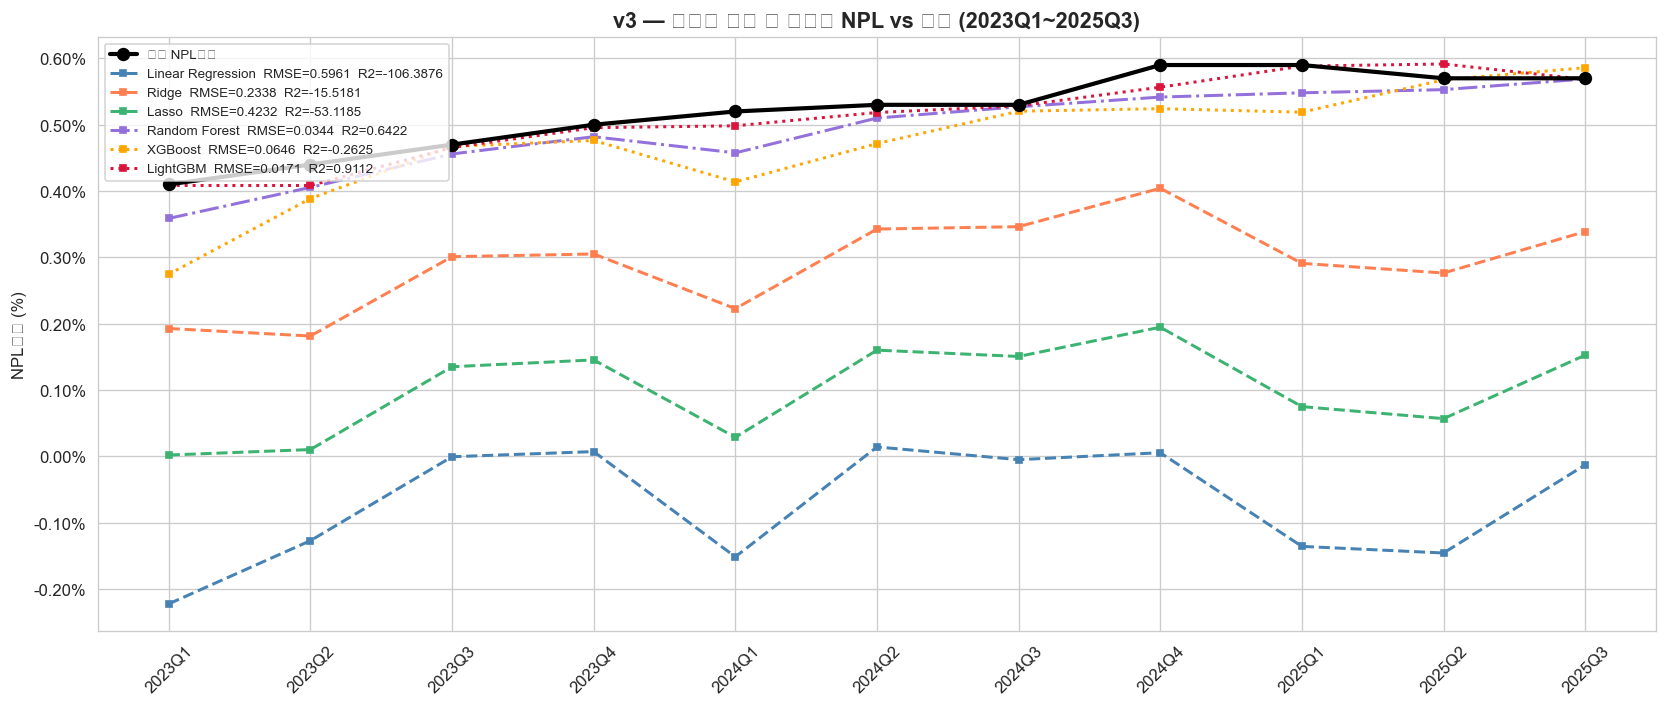

In [7]:
# -------------------------------------------------------
# 6. 예측 vs 실제 시계열
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

x_range = range(len(test_quarters))
ax.plot(x_range, y_test_npl, 'ko-', linewidth=2.5,
        markersize=7, label='실제 NPL비율', zorder=5)

colors     = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'orange', 'crimson']
linestyles = ['--', '--', '--', '-.', ':', ':']

for (name, pred_npl), color, ls in zip(pred_npl_dict.items(), colors, linestyles):
    rmse = result_df.loc[result_df['모델'] == name, 'RMSE(Test)'].values[0]
    r2   = result_df.loc[result_df['모델'] == name, 'R2(Test)'].values[0]
    ax.plot(x_range, pred_npl, color=color, linestyle=ls, linewidth=1.8,
            marker='s', markersize=4,
            label=f'{name}  RMSE={rmse}  R2={r2}')

ax.set_xticks(x_range)
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('NPL비율 (%)')
ax.set_title('v3 — 변화량 예측 후 복원한 NPL vs 실제 (2023Q1~2025Q3)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))
plt.tight_layout()
plt.savefig('../data/processed/fig_v3_prediction.png', bbox_inches='tight')
plt.show()

최고 성능 모델: LightGBM
  RMSE : 0.0171%
  MAE  : 0.0123%
  R2   : 0.9112
  MAPE : 2.37%


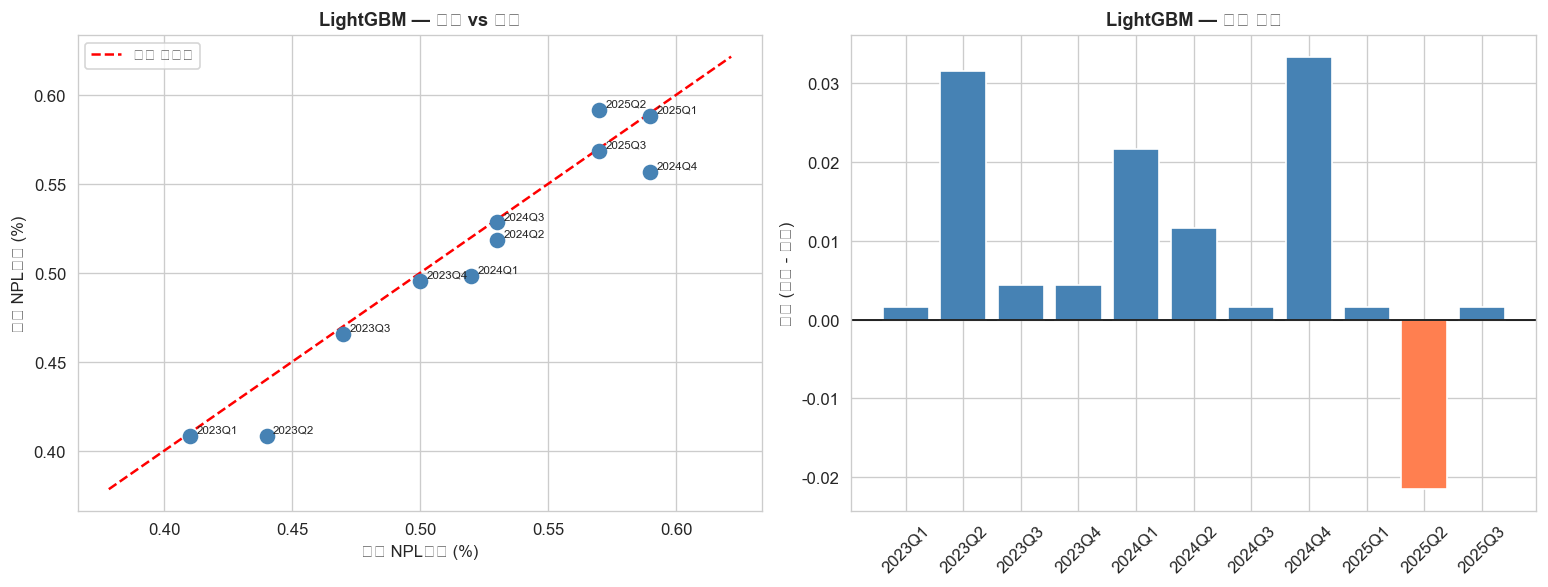

In [8]:
# -------------------------------------------------------
# 7. 최고 성능 모델 심층 분석
# -------------------------------------------------------
best_name    = result_df.iloc[0]['모델']
best_pred    = pred_npl_dict[best_name]
residuals    = y_test_npl - best_pred

print(f'최고 성능 모델: {best_name}')
print(f'  RMSE : {result_df.iloc[0]["RMSE(Test)"]:.4f}%')
print(f'  MAE  : {result_df.iloc[0]["MAE(Test)"]:.4f}%')
print(f'  R2   : {result_df.iloc[0]["R2(Test)"]:.4f}')
print(f'  MAPE : {result_df.iloc[0]["MAPE(Test)"]:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test_npl, best_pred, color='steelblue', s=70, zorder=3)
lim = [min(y_test_npl.min(), best_pred.min()) - 0.03,
       max(y_test_npl.max(), best_pred.max()) + 0.03]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='완벽 예측선')
for actual, pred, q in zip(y_test_npl, best_pred, test_quarters):
    ax.annotate(q, (actual, pred), textcoords='offset points',
                xytext=(4, 2), fontsize=7)
ax.set_xlabel('실제 NPL비율 (%)')
ax.set_ylabel('예측 NPL비율 (%)')
ax.set_title(f'{best_name} — 실제 vs 예측', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(range(len(test_quarters)), residuals,
       color=['coral' if r < 0 else 'steelblue' for r in residuals],
       edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(test_quarters)))
ax.set_xticklabels(test_quarters, rotation=45)
ax.set_ylabel('잔차 (실제 - 예측)')
ax.set_title(f'{best_name} — 잔차 분석', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/fig_v3_best.png', bbox_inches='tight')
plt.show()

In [9]:
# -------------------------------------------------------
# 8. 분기별 상세 결과
# -------------------------------------------------------
def next_quarter_label(q):
    year, qnum = int(q[:4]), int(q[-1])
    return f'{year}Q{qnum+1}' if qnum < 4 else f'{year+1}Q1'

detail_df = pd.DataFrame({
    '입력분기':            test_quarters,
    '예측대상분기':        [next_quarter_label(q) for q in test_quarters],
    '실제NPL(%)':         y_test_npl.round(3),
    f'예측(%)':           best_pred.round(3),
    '오차(%)':            residuals.round(3),
    '방향예측정확':       ['+' if (r * d) >= 0 else 'X'
                           for r, d in zip(residuals, y_test_diff.values)],
})
print(f'=== {best_name} 분기별 예측 결과 ===')
print(detail_df.to_string(index=False))
print(f'\n평균 절대 오차 : {np.abs(residuals).mean():.4f}%')
print(f'MAPE           : {np.mean(np.abs(residuals/y_test_npl))*100:.2f}%')

=== LightGBM 분기별 예측 결과 ===
  입력분기 예측대상분기  실제NPL(%)  예측(%)  오차(%) 방향예측정확
2023Q1 2023Q2      0.41  0.408  0.002      +
2023Q2 2023Q3      0.44  0.408  0.032      +
2023Q3 2023Q4      0.47  0.466  0.004      +
2023Q4 2024Q1      0.50  0.496  0.004      +
2024Q1 2024Q2      0.52  0.498  0.022      +
2024Q2 2024Q3      0.53  0.518  0.012      +
2024Q3 2024Q4      0.53  0.528  0.002      +
2024Q4 2025Q1      0.59  0.557  0.033      +
2025Q1 2025Q2      0.59  0.588  0.002      +
2025Q2 2025Q3      0.57  0.592 -0.022      +
2025Q3 2025Q4      0.57  0.568  0.002      +

평균 절대 오차 : 0.0123%
MAPE           : 2.37%


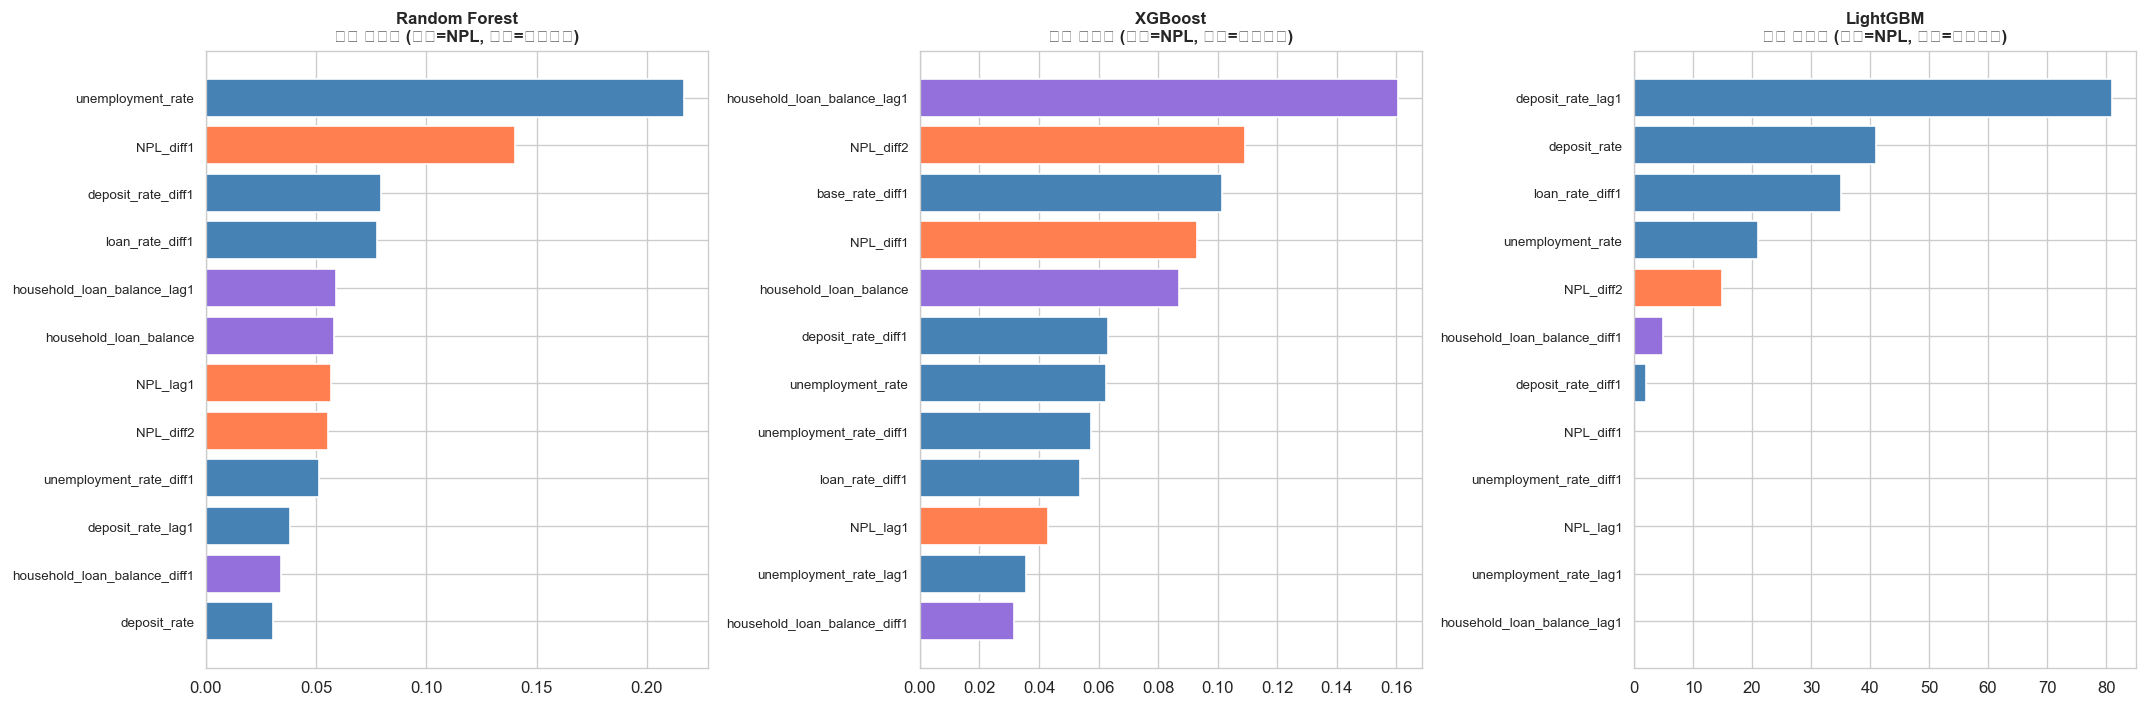

In [10]:
# -------------------------------------------------------
# 9. 피처 중요도 (변화량 예측 기준)
# -------------------------------------------------------
tree_models_v3 = {
    'Random Forest': models['Random Forest'][0],
    'XGBoost':       models['XGBoost'][0],
    'LightGBM':      models['LightGBM'][0],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, model) in zip(axes, tree_models_v3.items()):
    imp_df = pd.DataFrame({'피처': feature_cols,
                           '중요도': model.feature_importances_})
    imp_df = imp_df.sort_values('중요도', ascending=True).tail(12)

    colors_imp = []
    for f in imp_df['피처']:
        if 'NPL' in f:
            colors_imp.append('coral')       # NPL 관련
        elif 'household' in f:
            colors_imp.append('mediumpurple')  # 가계대출
        else:
            colors_imp.append('steelblue')

    ax.barh(imp_df['피처'], imp_df['중요도'],
            color=colors_imp, edgecolor='white')
    ax.set_title(f'{name}\n피처 중요도 (빨강=NPL, 보라=가계대출)',
                 fontsize=10, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_v3_importance.png', bbox_inches='tight')
plt.show()

## v3 모델링 요약

| 항목 | 내용 |
|------|------|
| 예측 방식 | NPL 변화량 예측 후 복원 |
| 최고 모델 | (결과 확인 후 기재) |
| 개선 여부 | R2 개선 여부 + RMSE 변화 확인 |